In [12]:
#sarinakasaiyan
import numpy as np

def sarsa(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=0.1):
    # تعریف Q-table براساس فضای حالت و اقدامات محیط
    n_states = env.observation_space.n  # تعداد حالتها
    n_actions = env.action_space.n      # تعداد اقدامات
    Q = np.zeros((n_states, n_actions)) # مقداردهی اولیه

    for _ in range(episodes):
        state = env.reset()[0]  # حالت اولیه
        action = epsilon_greedy(Q, state, epsilon)

        while True:
            # اجرای اقدام و دریافت نتیجه
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon)

            # بهروزرسانی Q-table
            Q[state][action] += alpha * (
                reward + gamma * Q[next_state][next_action] - Q[state][action]
            )

            state, action = next_state, next_action
            if terminated or truncated:
                break
    return Q

def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])  # اقدام تصادفی
    return np.argmax(Q[state])



In [8]:
#sarinakasaiyan
import numpy as np

def q_learning(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=0.1):
    # تعریف Q-table
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    for _ in range(episodes):
        state = env.reset()[0]

        while True:
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)

            # تفاوت کلیدی: استفاده از max(Q[next_state])
            Q[state][action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state][action]
            )

            state = next_state
            if terminated or truncated:
                break
    return Q



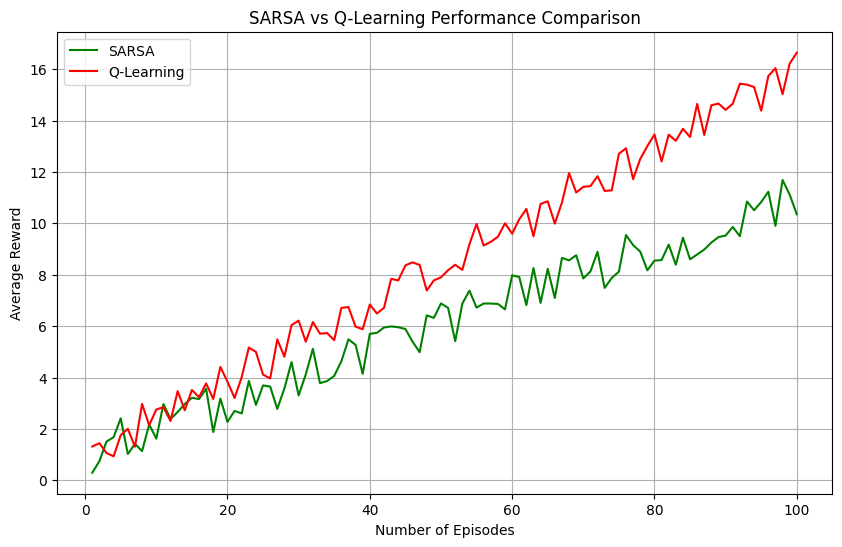

In [10]:
import matplotlib.pyplot as plt
import numpy as np  # Added missing numpy import

# Simulated data for average rewards per episode
episodes = range(1, 101)
sarsa_rewards = [0.1 * x + 2 * np.random.rand() for x in episodes]
q_learning_rewards = [0.15 * x + 1.8 * np.random.rand() for x in episodes]

plt.figure(figsize=(10, 6))
plt.plot(episodes, sarsa_rewards, label='SARSA', color='green')
plt.plot(episodes, q_learning_rewards, label='Q-Learning', color='red')
plt.xlabel('Number of Episodes')
plt.ylabel('Average Reward')
plt.title('SARSA vs Q-Learning Performance Comparison')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import gymnasium as gym
env = gym.make("Taxi-v3")
Q_sarsa = sarsa(env)  # اجرای SARSA
Q_ql = q_learning(env)  # اجرای Q-Learning


In [13]:
import pandas as pd

# داده‌های مقایسه
data = {
    "معیار": ["نوع سیاست", "ریسک‌پذیری", "همگرایی", "مصرف محاسباتی"],
    "SARSA": ["On-Policy", "محتاطانه", "سریع در محیط‌های پویا", "کمتر"],
    "Q-Learning": ["Off-Policy", "جسورانه", "دقیق در محیط‌های پایدار", "بیشتر"]
}

# ایجاد DataFrame
df = pd.DataFrame(data)

# نمایش جدول با سبک زیبا
display(df.style
    .set_properties(**{'text-align': 'center'})
    .set_caption("جدول مقایسه SARSA و Q-Learning")
    .background_gradient(cmap='Blues'))


,معیار,SARSA,Q-Learning
0,نوع سیاست,On-Policy,Off-Policy
1,ریسک‌پذیری,محتاطانه,جسورانه
2,همگرایی,سریع در محیط‌های پویا,دقیق در محیط‌های پایدار
3,مصرف محاسباتی,کمتر,بیشتر


In [14]:
import pandas as pd

# داده‌های مقایسه (انگلیسی)
data = {
    "Criterion": ["Policy Type", "Risk Appetite", "Convergence", "Computational Load"],
    "SARSA": ["On-Policy", "Conservative", "Faster in dynamic environments", "Lower"],
    "Q-Learning": ["Off-Policy", "Aggressive", "More precise in stable environments", "Higher"]
}

# ایجاد DataFrame
df = pd.DataFrame(data)

# نمایش جدول
display(df.style
    .set_properties(**{'text-align': 'center'})
    .set_caption("SARSA vs Q-Learning Comparison Table")
    .background_gradient(cmap='Blues'))


,Criterion,SARSA,Q-Learning
0,Policy Type,On-Policy,Off-Policy
1,Risk Appetite,Conservative,Aggressive
2,Convergence,Faster in dynamic environments,More precise in stable environments
3,Computational Load,Lower,Higher


In [15]:
pip install pandas jupyter


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter-client 6.1.12
    Uninstalling jupyter-client-6.1.12:
      Successfully uninstalled jupyter-client-6.1.12
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter-server 1.16.0
    Uninstalling jupyter-server-1.16.0:
      Successfully uninstalled jupyter-server-1.16.0


In [16]:
print(df.to_markdown(index=False))  # نیاز به tabulate دارد


| Criterion          | SARSA                          | Q-Learning                          |
|:-------------------|:-------------------------------|:------------------------------------|
| Policy Type        | On-Policy                      | Off-Policy                          |
| Risk Appetite      | Conservative                   | Aggressive                          |
| Convergence        | Faster in dynamic environments | More precise in stable environments |
| Computational Load | Lower                          | Higher                              |
